# Phase 2E: prospective relationship-selection diagnostics

## Purpose and scope

This notebook tests whether Phase 2D's provisional geometric motifs survive relationships chosen by **rules fixed before subsequent movement is inspected**. It uses only Metrica Sample Game 1 and the exact seven Phase 2D windows. This is a selection-method diagnostic, not motif detection or classification.

All geometry is shown in documented 105 × 68 m pitch units. Selection uses raw coordinates at a fixed reference frame. No smoothing, derivative, optimized cutoff, role inference, marking assignment, score, or model is used. Start-based selections are primary. Anchor-based nearest selections are reported separately as sensitivity checks and never substituted after seeing later movement.

Changing distance means only changing geometry: it does not establish responsibility, openness, intent, success, or causality.

In [1]:
from pathlib import Path
import hashlib,itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'
HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'; AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'; EVENT_PATH=DATA/'Sample_Game_1_RawEventsData.csv'
LENGTH,WIDTH=105.,68.
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
display(pd.DataFrame({'file':[p.name for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)],'sha256':[sha256(p) for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)]}))

def load_tracking(path,team):
    h=pd.read_csv(path,header=None,nrows=3); ids=[str(int(float(v))) for v in h.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for p in ids: cols += [f'{team}_{p}_x',f'{team}_{p}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ids
home,hp=load_tracking(HOME_PATH,'Home'); away,ap=load_tracking(AWAY_PATH,'Away'); events=pd.read_csv(EVENT_PATH)
tracking={'Home':home,'Away':away}; players={'Home':hp,'Away':ap}; goalkeeper={'Home':'11','Away':'25'}
print({'Home':home.shape,'Away':away.shape,'events':events.shape})

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


{'Home': (145006, 33), 'Away': (145006, 33), 'events': (1745, 14)}


## Fixed cases

These windows and focal players are inherited unchanged. Previously highlighted opponents are retained only for comparison with the prospective rules; they do not determine the new selections.

In [2]:
CASES=[
 {'name':'coordinated collective movement','short':'1888 translation','period':1,'start':1888.0,'end':1896.0,'def_team':'Home','focal':'2','opp_team':'Away','prior_opponent':None},
 {'name':'apparent focal excursion','short':'590 excursion','period':1,'start':590.0,'end':598.0,'def_team':'Home','focal':'2','opp_team':'Away','prior_opponent':'23'},
 {'name':'tackle / engagement','short':'550.76 tackle','period':1,'start':550.76,'end':555.76,'def_team':'Away','focal':'16','opp_team':'Home','prior_opponent':'9','anchor':550.76},
 {'name':'1230.12 interior compression','short':'1230 compression','period':1,'start':1228.12,'end':1232.12,'def_team':'Away','focal':'19','opp_team':'Home','prior_opponent':'10','anchor':1230.12},
 {'name':'accommodation / compression sequence','short':'1232 accommodation','period':1,'start':1229.28,'end':1234.28,'def_team':'Away','focal':'19','opp_team':'Home','prior_opponent':'10','anchor':1232.28},
 {'name':'collective-translation contrast','short':'3682 overlap','period':2,'start':3679.88,'end':3684.88,'def_team':'Home','focal':'8','opp_team':'Away','prior_opponent':'15','anchor':3682.88},
 {'name':'4197.04 heterogeneous negative','short':'4197 negative','period':2,'start':4195.04,'end':4199.04,'def_team':'Away','focal':'16','opp_team':'Home','prior_opponent':'10','anchor':4197.04},
]
display(pd.DataFrame(CASES)[['name','period','start','end','def_team','focal','opp_team','prior_opponent']])

,name,period,start,end,def_team,focal,opp_team,prior_opponent
0,coordinated collective movement,1,1888.00,1896.00,Home,2,Away,None
1,apparent focal excursion,1,590.00,598.00,Home,2,Away,23
2,tackle / engagement,1,550.76,555.76,Away,16,Home,9
3,1230.12 interior compression,1,1228.12,1232.12,Away,19,Home,10
4,accommodation / compression sequence,1,1229.28,1234.28,Away,19,Home,10
5,collective-translation contrast,2,3679.88,3684.88,Home,8,Away,15
6,4197.04 heterogeneous negative,2,4195.04,4199.04,Away,16,Home,10


## Rules fixed before inspection

| Relationship type | Prospective rule | Fixed convention | Main limitation anticipated |
|---|---|---|---|
| Defender–defender | nearest 1 / nearest 2 | Euclidean pitch distance from focal defender at window start | Proximity need not mean a stable functional relationship |
| Defender–defender | local radius | All outfield teammates within **15 m** of focal defender at start | 15 m is an illustrative, non-optimized radius; set size varies |
| Defender–defender | depth / lateral neighbor | Minimum absolute x difference / y difference at start | Ordering may select spatially close values on only one component |
| Defender–defender | fixed trio | Focal plus two nearest outfield teammates at start | Can become stale during rotation or crossing movement |
| Defender–opponent | nearest 1 / nearest 2 | Euclidean distance from focal at start | Mainly represents proximity, not responsibility |
| Defender–opponent | nearest to local trio | For each fixed-trio defender, its nearest opponent at start; duplicates retained once | May create a broad set and mix distinct contexts |
| Defender–opponent | nearest to trio centroid | Euclidean distance to fixed trio centroid at start | A centroid can hide which trio member is locally relevant |

Player identity is never re-selected to improve a motif. Dynamic nearest identity is calculated only as a churn/staleness contrast. The radius and neighbor counts are not tuned.

In [3]:
def case_window(case):
    d=tracking[case['def_team']]; o=tracking[case['opp_team']]
    w=d[(d.Period==case['period'])&d['Time [s]'].between(case['start'],case['end'])].copy()
    cols=['Frame']+[f"{case['opp_team']}_{p}_{a}" for p in players[case['opp_team']] for a in ('x','y')]
    return w.merge(o[cols],on='Frame',validate='one_to_one')
def outfield(team): return [p for p in players[team] if p!=goalkeeper[team]]
def xy(r,team,p): return np.array([r[f'{team}_{p}_x']*LENGTH,r[f'{team}_{p}_y']*WIDTH],float)
def valid_dist(r,team,a,b):
    u,v=xy(r,team,a),xy(r,team,b)
    return np.linalg.norm(u-v) if np.isfinite(u).all() and np.isfinite(v).all() else np.nan
def reference_row(w,t): return w.iloc[(w['Time [s]']-t).abs().argmin()]
def nearest_to_point(r,team,ids,point,n):
    vals=[]
    for p in ids:
        q=xy(r,team,p)
        if np.isfinite(q).all(): vals.append((float(np.linalg.norm(q-point)),p))
    return [p for _,p in sorted(vals)[:n]]
def select(case,w,t):
    r=reference_row(w,t); dt,ot=case['def_team'],case['opp_team']; f=case['focal']; fp=xy(r,dt,f)
    mates=[p for p in outfield(dt) if p!=f]
    near2=nearest_to_point(r,dt,mates,fp,2)
    radius=[p for p in mates if valid_dist(r,dt,f,p)<=15.]
    finite=[p for p in mates if np.isfinite(xy(r,dt,p)).all()]
    depth=min(finite,key=lambda p:abs(xy(r,dt,p)[0]-fp[0])); lateral=min(finite,key=lambda p:abs(xy(r,dt,p)[1]-fp[1]))
    trio=[f]+near2
    opps=outfield(ot)
    opp1=nearest_to_point(r,ot,opps,fp,1); opp2=nearest_to_point(r,ot,opps,fp,2)
    trio_opps=[]
    for d in trio:
        for p in nearest_to_point(r,ot,opps,xy(r,dt,d),1):
            if p not in trio_opps: trio_opps.append(p)
    tc=np.nanmean([xy(r,dt,p) for p in trio],axis=0)
    return {'dd_nearest1':near2[:1],'dd_nearest2':near2,'dd_radius15':radius,'dd_depth_lateral':list(dict.fromkeys([depth,lateral])),
            'dd_trio':trio,'do_nearest1':opp1,'do_nearest2':opp2,'do_trio_nearest':trio_opps,'do_trio_centroid':nearest_to_point(r,ot,opps,tc,1)}
def add_base(case):
    w=case_window(case); dt=case['def_team']; ids=outfield(dt); refs=[p for p in ids if p!=case['focal']]
    w['centroid_x_m']=w[[f'{dt}_{p}_x' for p in ids]].mean(axis=1)*LENGTH; w['centroid_y_m']=w[[f'{dt}_{p}_y' for p in ids]].mean(axis=1)*WIDTH
    w['loo_x_m']=w[[f'{dt}_{p}_x' for p in refs]].mean(axis=1)*LENGTH; w['loo_y_m']=w[[f'{dt}_{p}_y' for p in refs]].mean(axis=1)*WIDTH
    w['focal_loo_x_m']=w[f'{dt}_{case["focal"]}_x']*LENGTH-w.loo_x_m; w['focal_loo_y_m']=w[f'{dt}_{case["focal"]}_y']*WIDTH-w.loo_y_m
    w['plot_t']=w['Time [s]']-case['start']; return w
for c in CASES:
    c['w']=add_base(c); c['start_sel']=select(c,c['w'],c['start'])
print('Selections use nearest available 25 Hz frame; no interpolation.')

Selections use nearest available 25 Hz frame; no interpolation.


## Start-fixed selections and anchor sensitivity

The table makes selection auditable before any relationship-change summary is shown. Anchor selections use the nearest recorded frame to the pre-existing anchor and are sensitivity checks only.

In [4]:
rows=[]
for c in CASES:
    s=c['start_sel']
    rows.append({'case':c['short'],'DD nearest 2':','.join(s['dd_nearest2']),'DD radius 15 m':','.join(s['dd_radius15']) or 'none',
                 'DD depth/lateral':','.join(s['dd_depth_lateral']),'DO nearest 2':','.join(s['do_nearest2']),
                 'DO trio-nearest':','.join(s['do_trio_nearest']),'DO trio-centroid':','.join(s['do_trio_centroid'])})
start_table=pd.DataFrame(rows).set_index('case'); display(start_table)

arows=[]
for c in CASES:
    if 'anchor' not in c: continue
    a=select(c,c['w'],c['anchor']); c['anchor_sel']=a
    arows.append({'case':c['short'],'start DD2':','.join(c['start_sel']['dd_nearest2']),'anchor DD2':','.join(a['dd_nearest2']),
                  'start DO1':','.join(c['start_sel']['do_nearest1']),'anchor DO1':','.join(a['do_nearest1']),
                  'prior highlighted opponent':c['prior_opponent']})
display(pd.DataFrame(arows).set_index('case'))

,DD nearest 2,DD radius 15 m,DD depth/lateral,DO nearest 2,DO trio-nearest,DO trio-centroid
case,,,,,,
1888 translation,"3,7","3,6,7","4,10","24,23","24,23",24
590 excursion,"3,1",3,"3,10","24,23","24,23",24
550.76 tackle,"17,15","15,17","15,20","9,10","9,10",9
1230 compression,"22,17","17,22,23","21,17","10,5","10,5",10
1232 accommodation,"22,23","17,22,23","21,23","10,5","10,5,6",6
3682 overlap,"10,5",10,"10,4","17,15","17,15,18",21
4197 negative,"15,19","15,18,19,21","20,23","10,9","10,9",10


,start DD2,anchor DD2,start DO1,anchor DO1,prior highlighted opponent
case,,,,,
550.76 tackle,"17,15","17,15",9,9,9
1230 compression,"22,17","22,23",10,10,10
1232 accommodation,"22,23","21,20",10,10,10
3682 overlap,"10,5","5,10",17,15,15
4197 negative,"15,19","19,15",10,10,10


## Churn and staleness diagnostics

Identity changes below are descriptive counts over each fixed window. “Retained” is the share of valid frames in which the start-nearest identity remains dynamically nearest. These are not stability scores or handoff detections. A changing nearest identity may reflect crossing paths, collective motion, or missingness; it may also preserve information that dynamic re-selection would erase.

In [5]:
def dynamic_nearest(case,w,target_team,target_ids,point_fn):
    ans=[]
    for _,r in w.iterrows():
        pt=point_fn(r); ids=nearest_to_point(r,target_team,target_ids,pt,1); ans.append(ids[0] if ids else None)
    return pd.Series(ans,index=w.index)
def changes(s):
    z=s.dropna(); return int((z!=z.shift()).iloc[1:].sum()) if len(z)>1 else 0
churn=[]
for c in CASES:
    w=c['w']; dt,ot,f=c['def_team'],c['opp_team'],c['focal']; s=c['start_sel']
    dyn_dd=dynamic_nearest(c,w,dt,[p for p in outfield(dt) if p!=f],lambda r:xy(r,dt,f))
    dyn_do=dynamic_nearest(c,w,ot,outfield(ot),lambda r:xy(r,dt,f))
    c['dyn_dd']=dyn_dd; c['dyn_do']=dyn_do
    dd0=s['dd_nearest1'][0]; do0=s['do_nearest1'][0]
    churn.append({'case':c['short'],'DD identity changes':changes(dyn_dd),'start DD1 retained %':100*(dyn_dd==dd0).mean(),
                  'DO identity changes':changes(dyn_do),'start DO1 retained %':100*(dyn_do==do0).mean(),
                  'DD identities':','.join(pd.unique(dyn_dd.dropna())),'DO identities':','.join(pd.unique(dyn_do.dropna()))})
churn_table=pd.DataFrame(churn).set_index('case'); display(churn_table.round(1))

,DD identity changes,start DD1 retained %,DO identity changes,start DO1 retained %,DD identities,DO identities
case,,,,,,
1888 translation,2,97.0,1,3.5,"3,7","24,23"
590 excursion,1,59.2,1,68.7,"3,1","24,23"
550.76 tackle,3,15.9,0,100.0,"17,15,18",9
1230 compression,1,71.3,0,100.0,"22,21",10
1232 accommodation,2,34.1,0,100.0,"22,21,20",10
3682 overlap,1,25.4,1,41.3,"10,5","17,15"
4197 negative,1,44.6,0,100.0,"15,19",10


## Raw selection-validity views

For the compression anchor, excursion, and heterogeneous negative case, the left panel fixes start-selected relationships on raw trajectories. The middle panels trace those same identities. The bottom-right panel shows dynamically nearest identity as a contrast—not as a replacement rule. Pitch traces and centroid context remain the basis for interpretation.

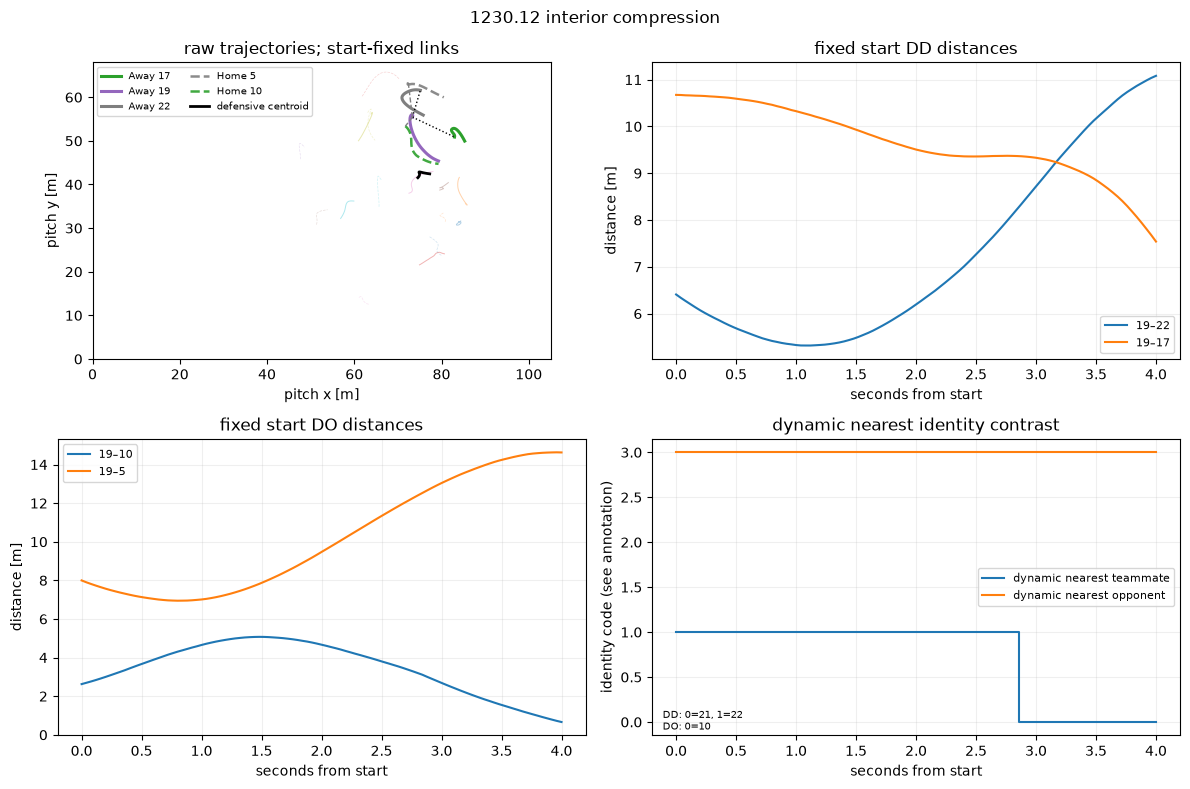

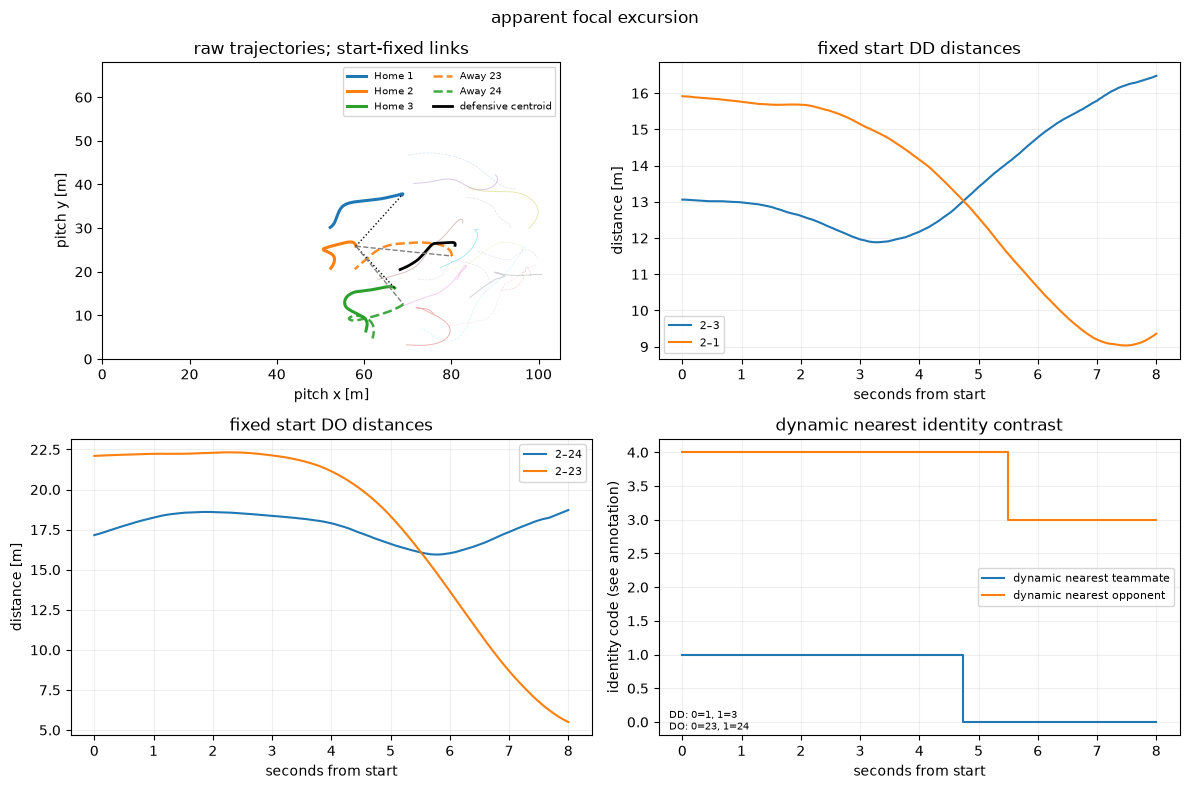

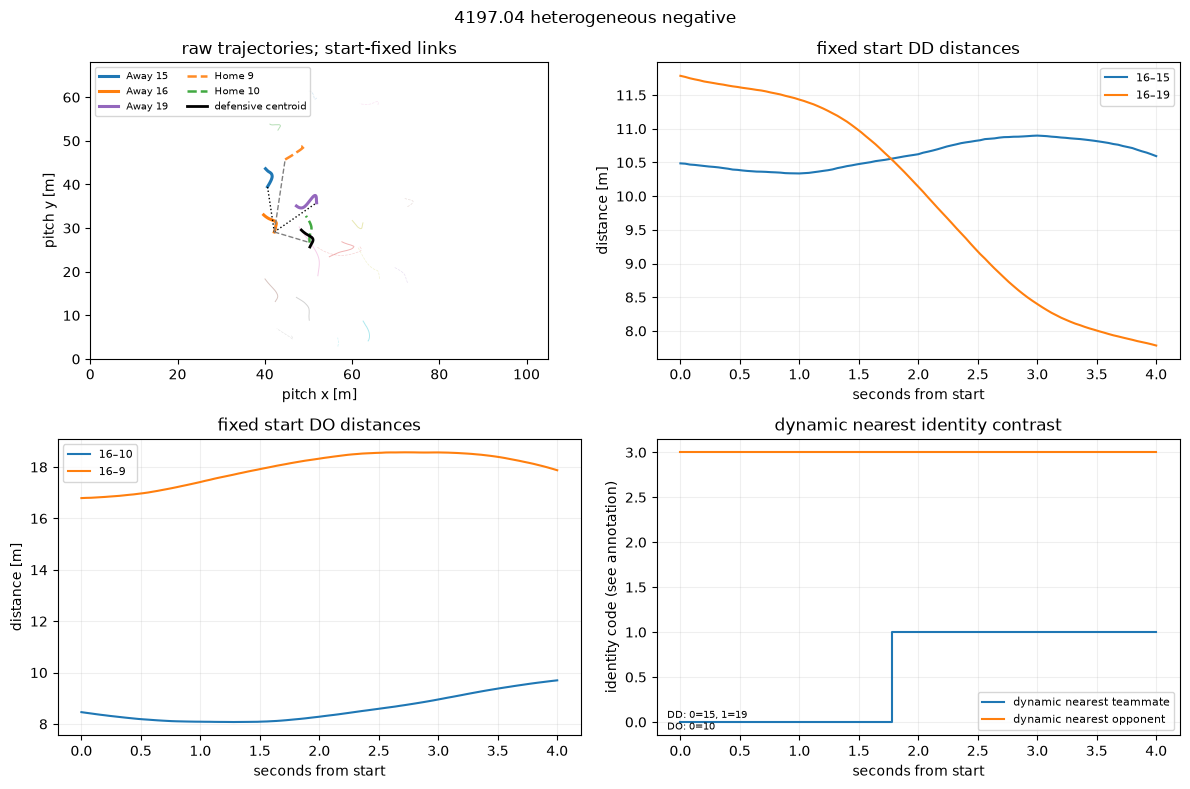

In [6]:
def pair_dist(w,ta,a,tb,b):
    return np.hypot((w[f'{ta}_{a}_x']-w[f'{tb}_{b}_x'])*LENGTH,(w[f'{ta}_{a}_y']-w[f'{tb}_{b}_y'])*WIDTH)
def draw_case(c):
    w=c['w']; dt,ot,f=c['def_team'],c['opp_team'],c['focal']; s=c['start_sel']; t=w['plot_t']
    fig,ax=plt.subplots(2,2,figsize=(12,8)); p=ax[0,0]
    for d in outfield(dt):
        hi=d in s['dd_trio']; p.plot(w[f'{dt}_{d}_x']*LENGTH,w[f'{dt}_{d}_y']*WIDTH,lw=2.2 if hi else .7,alpha=1 if hi else .35,label=f'{dt} {d}' if hi else None)
    for o in outfield(ot):
        hi=o in s['do_nearest2']; p.plot(w[f'{ot}_{o}_x']*LENGTH,w[f'{ot}_{o}_y']*WIDTH,ls='--',lw=1.8 if hi else .5,alpha=.9 if hi else .2,label=f'{ot} {o}' if hi else None)
    p.plot(w.centroid_x_m,w.centroid_y_m,c='black',lw=2,label='defensive centroid')
    r=w.iloc[0]; fp=xy(r,dt,f)
    for d in s['dd_nearest2']:
        q=xy(r,dt,d); p.plot([fp[0],q[0]],[fp[1],q[1]],c='black',ls=':',lw=1)
    for o in s['do_nearest2']:
        q=xy(r,ot,o); p.plot([fp[0],q[0]],[fp[1],q[1]],c='grey',ls='--',lw=1)
    p.set(xlim=(0,LENGTH),ylim=(0,WIDTH),aspect='equal',title='raw trajectories; start-fixed links',xlabel='pitch x [m]',ylabel='pitch y [m]'); p.legend(fontsize=7,ncol=2)
    q=ax[0,1]
    for d in s['dd_nearest2']: q.plot(t,pair_dist(w,dt,f,dt,d),label=f'{f}–{d}')
    q.set(title='fixed start DD distances',xlabel='seconds from start',ylabel='distance [m]'); q.legend(fontsize=8); q.grid(alpha=.2)
    q=ax[1,0]
    for o in s['do_nearest2']: q.plot(t,pair_dist(w,dt,f,ot,o),label=f'{f}–{o}')
    q.set(title='fixed start DO distances',xlabel='seconds from start',ylabel='distance [m]'); q.legend(fontsize=8); q.grid(alpha=.2)
    q=ax[1,1]; dd_codes=pd.Categorical(c['dyn_dd']).codes; do_codes=pd.Categorical(c['dyn_do']).codes
    q.step(t,dd_codes,where='mid',label='dynamic nearest teammate'); q.step(t,do_codes+max(dd_codes.max()+2,2),where='mid',label='dynamic nearest opponent')
    q.set(title='dynamic nearest identity contrast',xlabel='seconds from start',ylabel='identity code (see annotation)'); q.grid(alpha=.2); q.legend(fontsize=8)
    q.text(.02,.02,'DD: '+', '.join(f'{i}={v}' for i,v in enumerate(pd.Categorical(c['dyn_dd']).categories))+'\nDO: '+', '.join(f'{i}={v}' for i,v in enumerate(pd.Categorical(c['dyn_do']).categories)),transform=q.transAxes,fontsize=7)
    fig.suptitle(c['name']); fig.tight_layout(); plt.show()
for key in ['1230 compression','590 excursion','4197 negative']:
    draw_case(next(c for c in CASES if c['short']==key))

## Motif summaries using prospective selections only

The summaries below keep channels separate. Net centroid movement and focal leave-one-out-centroid movement describe collective and focal channels. Each defender-pair cell lists raw start-to-end distance changes for the pair(s) generated by that rule. Opponent cells do the same for prospectively selected opponents. No values are summed or thresholded.

In [7]:
def net_xy(x,y):
    a=np.array([x.iloc[0],y.iloc[0]],float); b=np.array([x.iloc[-1],y.iloc[-1]],float); return float(np.linalg.norm(b-a))
def changes_for(w,team,f,ids,other_team=None):
    tt=other_team or team
    vals=[]
    for p in ids:
        d=pair_dist(w,team,f,tt,p); vals.append(float(d.iloc[-1]-d.iloc[0]))
    return vals
def fmt(v): return ', '.join(f'{x:+.2f}' for x in v) if v else 'none selected'
rows=[]
for c in CASES:
    w,s,dt,ot,f=c['w'],c['start_sel'],c['def_team'],c['opp_team'],c['focal']
    rows.append({'case':c['short'],'centroid net [m]':net_xy(w.centroid_x_m,w.centroid_y_m),'focal LOO net [m]':net_xy(w.focal_loo_x_m,w.focal_loo_y_m),
                 'DD nearest2 Δdistance [m]':fmt(changes_for(w,dt,f,s['dd_nearest2'])),
                 'DD radius Δdistance [m]':fmt(changes_for(w,dt,f,s['dd_radius15'])),
                 'DD depth/lateral Δdistance [m]':fmt(changes_for(w,dt,f,s['dd_depth_lateral'])),
                 'DO nearest2 Δdistance [m]':fmt(changes_for(w,dt,f,s['do_nearest2'],ot)),
                 'DO trio-centroid selected / focal Δdistance [m]':','.join(s['do_trio_centroid'])+' / '+fmt(changes_for(w,dt,f,s['do_trio_centroid'],ot))})
prospective=pd.DataFrame(rows).set_index('case'); display(prospective)

,centroid net [m],focal LOO net [m],DD nearest2 Δdistance [m],DD radius Δdistance [m],DD depth/lateral Δdistance [m],DO nearest2 Δdistance [m],DO trio-centroid selected / focal Δdistance [m]
case,,,,,,,
1888 translation,31.021137,2.098990,"-0.46, +2.67","-0.46, -1.34, +2.67","-2.99, +9.59","+1.60, -5.20",24 / +1.60
590 excursion,13.762592,7.625248,"+3.42, -6.56",+3.42,"+3.42, -3.21","+1.56, -16.60",24 / +1.56
550.76 tackle,18.992653,13.805746,"+5.29, -11.71","-11.71, +5.29","-11.71, +4.40","-9.79, +7.02",9 / -9.79
1230 compression,2.856295,12.674551,"+4.67, -3.13","-3.13, +4.67, +5.32","-14.73, -3.13","-1.96, +6.63",10 / -1.96
1232 accommodation,3.786465,11.629982,"+3.09, +12.57","-5.64, +3.09, +12.57","-12.74, +12.57","+0.04, +2.24",6 / +1.31
3682 overlap,19.313905,12.246798,"+8.85, -2.99",+8.85,"+8.85, +16.59","+1.10, -7.49",21 / +7.58
4197 negative,4.352826,0.524315,"+0.11, -4.00","+0.11, +5.12, -4.00, -5.56","-1.26, -0.08","+1.24, +1.08",10 / +1.24


## Rule-level robustness checks

The next table exposes how rule choice changes the selected identities and contraction story. “Contracting pairs” is a literal count of negative start-to-end distance changes among the displayed fixed pairs, not a motif score or decision rule.

In [8]:
rr=[]
for c in CASES:
    w,s,dt,ot,f=c['w'],c['start_sel'],c['def_team'],c['opp_team'],c['focal']
    for rule in ['dd_nearest2','dd_radius15','dd_depth_lateral']:
        vals=changes_for(w,dt,f,s[rule])
        rr.append({'case':c['short'],'rule':rule,'selected':','.join(s[rule]) or 'none','pair changes [m]':fmt(vals),'contracting pairs':sum(v<0 for v in vals),'pairs shown':len(vals)})
rule_table=pd.DataFrame(rr); display(rule_table.set_index(['case','rule']))

selected            pair changes [m]  \
case               rule                                                        
1888 translation   dd_nearest2               3,7                -0.46, +2.67   
                   dd_radius15             3,6,7         -0.46, -1.34, +2.67   
                   dd_depth_lateral         4,10                -2.99, +9.59   
590 excursion      dd_nearest2               3,1                +3.42, -6.56   
                   dd_radius15                 3                       +3.42   
                   dd_depth_lateral         3,10                +3.42, -3.21   
550.76 tackle      dd_nearest2             17,15               +5.29, -11.71   
                   dd_radius15             15,17               -11.71, +5.29   
                   dd_depth_lateral        15,20               -11.71, +4.40   
1230 compression   dd_nearest2             22,17                +4.67, -3.13   
                   dd_radius15          17,22,23         -3.13, +4.67, +5.32   
                   dd_depth_lateral        21,17               -14.73, -3.13   
1232 accommodation dd_nearest2             22,23               +3.09, +12.57   
                   dd_radius15          17,22,23        -5.64, +3.09, +12.57   
                   dd_depth_lateral        21,23              -12.74, +12.57   
3682 overlap       dd_nearest2              10,5                +8.85, -2.99   
                   dd_radius15                10                       +8.85   
                   dd_depth_lateral         10,4               +8.85, +16.59   
4197 negative      dd_nearest2             15,19                +0.11, -4.00   
                   dd_radius15       15,18,19,21  +0.11, +5.12, -4.00, -5.56   
                   dd_depth_lateral        20,23                -1.26, -0.08   

                                     contracting pairs  pairs shown  
case               rule                                              
1888 translation   dd_nearest2                       1            2  
                   dd_radius15                       2            3  
                   dd_depth_lateral                  1            2  
590 excursion      dd_nearest2                       1            2  
                   dd_radius15                       0            1  
                   dd_depth_lateral                  1            2  
550.76 tackle      dd_nearest2                       1            2  
                   dd_radius15                       1            2  
                   dd_depth_lateral                  1            2  
1230 compression   dd_nearest2                       1            2  
                   dd_radius15                       1            3  
                   dd_depth_lateral                  2            2  
1232 accommodation dd_nearest2                       0            2  
                   dd_radius15                       1            3  
                   dd_depth_lateral                  1            2  
3682 overlap       dd_nearest2                       1            2  
                   dd_radius15                       0            1  
                   dd_depth_lateral                  0            2  
4197 negative      dd_nearest2                       1            2  
                   dd_radius15                       2            4  
                   dd_depth_lateral                  2            2

## Interpretation and falsification

The executed tables and raw-geometry panels support a deliberately limited conclusion:

- **Coordinated translation:** survives prospective selection because the large centroid displacement is directly observed and start-fixed defender relationships remain a separate, imperfectly rigid channel. It does not require a hand-picked opponent.
- **Focal excursion:** remains visible through focal leave-one-out movement and start-nearest teammate relationships. Its opponent story is more rule-sensitive: nearest-opponent selection describes proximity and may differ from the historically illustrated Player23 relationship.
- **1230.12 local compression:** the Phase 2D conclusion does **not** survive uniformly. Start-nearest-two and 15 m rules each show only one contraction alongside expansion; the depth/lateral rule selects Players21 and17 and shows two contractions. The previously illustrated 19–20–21 neighborhood is therefore not recovered by the primary proximity rule. This downgrades compression to rule-sensitive evidence rather than rescuing it with post-window selection.
- **3682.88 overlap:** large translation survives, but prospective compression evidence is weak and rule-dependent: nearest-two has one contraction and one large expansion, while radius and depth/lateral views do not show multi-pair contraction. The earlier translation + compression reading is retained as an overlap hypothesis, not reproduced robustly by these start rules.
- **Tackle/engagement and accommodation:** remain ambiguous/overlapping because prospective rules do not turn mixed collective, focal, and pair geometry into one clean description.
- **4197.04 negative:** remains mixed/no-clean-motif across reasonable rules. Some prospectively chosen pairs contract, but radius-selected relationships contain both substantial expansion and contraction, while collective and focal-relative channels do not form the canonical compression or excursion pattern. No relationship is substituted to make it positive.

### Staleness, churn, and alternatives

Start-fixed selections preserve the identity of a relationship and therefore expose when it becomes stale. Dynamic nearest selection can look locally current but introduces identity switches, discontinuities, and loss of the very fixed-pair excursion or redistribution path being studied. Churn may eventually be useful descriptive evidence, but it is not a handoff metric here. Ball and collective movement remain visible alternative explanations for shared motion.

Nearest-opponent rules mostly reproduce proximity. They do not validate marking, threat, access, openness, or responsibility. Reasonable rules can select different opponents and therefore yield different geometric stories; this is a substantive limitation rather than noise to optimize away.

## Conservative recommendations

| Relationship type | Assessment | Current Phase 2 default |
|---|---|---|
| Defender–defender | **Usable but context-sensitive.** Start-fixed focal + two nearest outfield teammates is transparent, identity-preserving, and nonempty, but it does not robustly recover the 1230 compression or 3682 overlap interpretation. Radius and depth/lateral selections can contradict it. | Start-fixed nearest-two / fixed trio as the reproducibility baseline, always shown on raw pitch geometry; report churn and rule sensitivity and do not treat motif failure as a reason to switch rules. |
| Defender–opponent | **Not yet reliable as a substantive defensive relationship; usable as prospective geometric context.** Nearest-one is brittle and nearest-two is less singular but still proximity-only. | Start-fixed nearest two opponents as a candidate context set, never as assignment; retain historically/event-justified opponent separately and label its provenance. |

There is no universal selector. Defender–defender and defender–opponent relationships require different logic. Anchor-time nearest selection can diagnose sensitivity where an anchor already exists, but it is not interchangeable with the primary start-based rule.

## Implication for falsifiability

Prospective selection makes the relational framework more falsifiable: a motif that disappears, reverses, or depends on switching rules after the window begins must be weakened rather than rescued. The current motifs survive unevenly. Shared translation and focal collective-relative excursion are comparatively robust because they depend less on a chosen opponent. Local compression is not robust to the tested neighborhood rules in the 1230 and 3682 cases, and opponent-specific interpretations remain the weakest. This is progress toward reproducibility precisely because it exposes a failure, not readiness for motif detection, handoff inference, attribution, or a general relational model.